In [1]:
from algs.cd_poly import CDPolynomial
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics.pairwise import rbf_kernel

In [2]:
m = 10
d = 3

In [3]:
x = 2 * np.random.rand(m)[:, np.newaxis] - 1
p = CDPolynomial(x, degree=d)

In [4]:
lims = -1.2, 1.2
t = np.linspace(lims[0], lims[1], 100)[:, np.newaxis]
pt = p(t)

In [39]:
poly = lambda x, y: (1 + x @ y.T) ** d
single_poly = lambda x: (1 + np.sum(x * x, axis=1)) ** d

rbf = lambda x, y: rbf_kernel(x, y, gamma=0.25)
single_rbf = lambda x: np.ones(len(x))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 1)

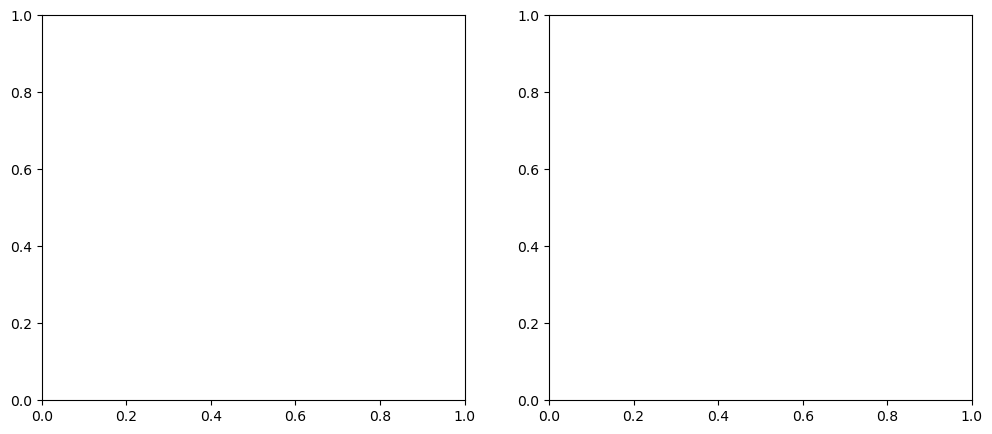

In [40]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

for i, k in enumerate([poly, rbf_kernel]):
    epsilons = np.logspace(-1, -4, base=10, num=10)
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(epsilons)))


    for eps, col in zip(epsilons, colors):
        qt = np.diag(k(t,t) - k(t, x) @ np.linalg.inv(k(x, x) + m * eps * np.eye(m)) @ k(x, t)) / eps
        ax[i].plot(t, qt, color=col, label=f'ε={eps:.3f}')

    ax[i].plot(t, pt, color='green', linewidth=3)
    ax[i].scatter(x.flatten(), np.zeros_like(x), marker='x', color='red')
    ax[i].legend()
    ax[i].set_yscale('log')

## 2D points

In [41]:
from sklearn.datasets import make_blobs

In [53]:
m = 200
x = make_blobs(m, centers=5)[0]

In [54]:
def kernelized(t, eps):
    K = poly(x, x) + len(x) * eps * np.eye(len(x)) # n_data, n_data
    kt = poly(t, x) # n_pts, n_data
    ktt = single_poly(t) # n_pts
    return (ktt - np.einsum('bi,ij,bj->b', kt, np.linalg.inv(K), kt)) / eps

def kernelized_rbf(t, eps):
    K = rbf(x, x) + len(x) * eps * np.eye(len(x)) # n_data, n_data
    kt = rbf(t, x) # n_pts, n_data
    ktt = single_rbf(t) # n_pts
    return (ktt - np.einsum('bi,ij,bj->b', kt, np.linalg.inv(K), kt)) / eps

Text(0.5, 1.0, 'kern. CD poly (rbf kernel)')

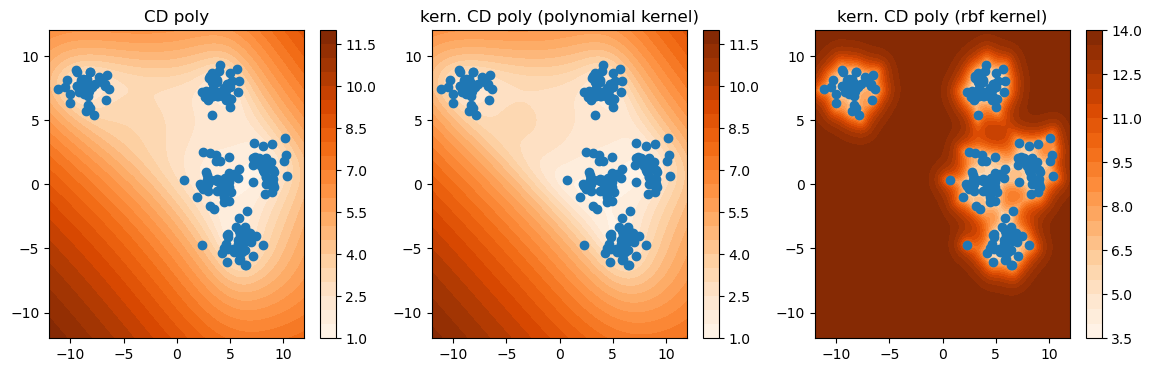

In [60]:
p = CDPolynomial(x, degree=d)
#p.plot(plt.gca())

fig, ax = plt.subplots(ncols=3, figsize=(14, 4))

# cd poly
xx, yy = np.meshgrid(np.linspace(-12, 12, 300), np.linspace(-12, 12, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]  # (num grid pts, 2)
p = CDPolynomial(x, degree=d)
zz = p(grid_points).reshape(xx.shape)
zz = np.log(zz)
contour = ax[0].contourf(xx, yy, zz, levels=20, cmap='Oranges')
fig.colorbar(contour, ax=ax[0])
ax[0].scatter(*x.T)
ax[0].set_title('CD poly')

# poly kernel
xx, yy = np.meshgrid(np.linspace(-12, 12, 300), np.linspace(-12, 12, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]  # (num grid pts, 2)

zz = kernelized(grid_points, 1e-1).reshape(xx.shape)
zz = np.log(zz)
contour = ax[1].contourf(xx, yy, zz, levels=20, cmap='Oranges')
fig.colorbar(contour, ax=ax[1])
ax[1].scatter(*x.T)
ax[1].set_title('kern. CD poly (polynomial kernel)')

# rbf kernel
xx, yy = np.meshgrid(np.linspace(-12, 12, 300), np.linspace(-12, 12, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]  # (num grid pts, 2)

zz = kernelized_rbf(grid_points, 1e-6).reshape(xx.shape)
zz = np.log(zz)
contour = ax[2].contourf(xx, yy, zz, levels=20, cmap='Oranges')
fig.colorbar(contour, ax=ax[2])
ax[2].scatter(*x.T)
ax[2].set_title('kern. CD poly (rbf kernel)')

## Comparing kernelized with Gaussian to KDE

In [11]:
from sklearn.neighbors import KernelDensity

In [12]:
m = 20
x = 2 * np.random.rand(m)[:, np.newaxis] - 1

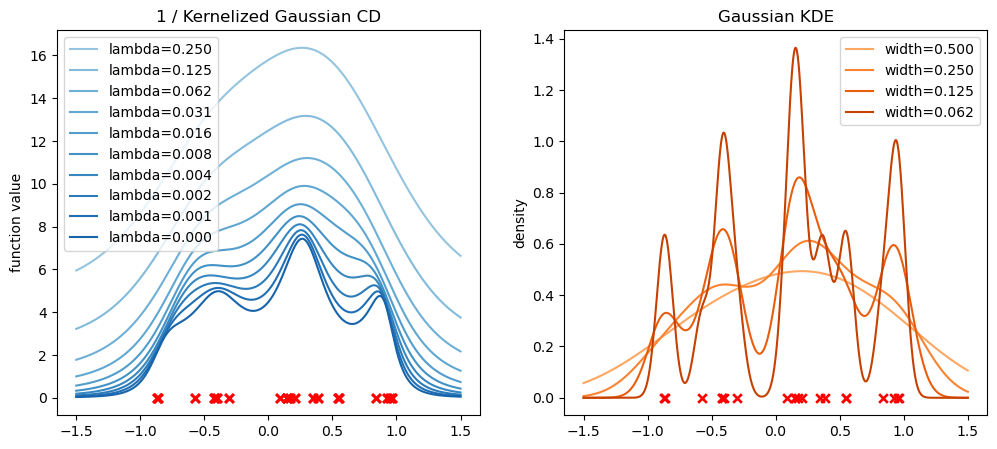

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

epsilons = 2. ** -np.arange(2, 12)
widths = 2. ** -np.arange(1, 5)

colors1 = plt.cm.Blues(np.linspace(0.4, 0.8, len(epsilons)))
colors2 = plt.cm.Oranges(np.linspace(0.4, 0.8, len(widths)))

t = np.linspace(-1.5, 1.5, 1000)[:, np.newaxis]

for eps, col in zip(epsilons, colors1):
    ax[0].scatter(x, np.zeros_like(x), marker='x', color='red')
    k = rbf_kernel
    y_cd = 20.3 / (np.diag(k(t,t) - k(t, x) @ np.linalg.inv(k(x, x) + m * eps * np.eye(m)) @ k(x, t)) / eps)
    ax[0].plot(t, y_cd, label=f'lambda={eps:.3f}', color=col)
    ax[0].legend()
    ax[0].set_title('1 / Kernelized Gaussian CD')
    ax[0].set_ylabel('function value')

for width, col in zip(widths, colors2):
    ax[1].scatter(x, np.zeros_like(x), marker='x', color='red')
    kde = KernelDensity(kernel='gaussian', bandwidth=width)
    kde.fit(x)
    y_kde = np.exp(kde.score_samples(t))
    ax[1].plot(t, y_kde, label=f'width={width:.3f}', color=col)
    ax[1].set_title('Gaussian KDE')
    ax[1].legend()
    ax[1].set_ylabel('density')